# **Skin Burns YOLO**

*prageethm*

In [8]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import shutil

from collections import Counter

In [9]:
DATASET_PATH = "/kaggle/input/skin-burn-dataset"

In [10]:
files = os.listdir(DATASET_PATH)
image_files = sorted([f for f in files if f.endswith((".jpg", ".jpeg", ".png"))])
label_files = sorted([f for f in files if f.endswith(".txt")])
image_names = {os.path.splitext(f)[0]: f for f in image_files}
label_names = {os.path.splitext(f)[0]: f for f in label_files}

file_data = []
for name in set(image_names.keys()).union(set(label_names.keys())):
    file_data.append({
        "Image File": image_names.get(name, "Missing"),
        "Label File": label_names.get(name, "Missing"),
        "Has Image": "Yes" if name in image_names else "No",
        "Has Label": "Yes" if name in label_names else "No"
    })
df = pd.DataFrame(file_data)
print(df.head(50))

     Image File   Label File Has Image Has Label
0     img26.jpg    img26.txt       Yes       Yes
1       Missing  img1218.txt        No       Yes
2   img1210.jpg  img1210.txt       Yes       Yes
3   img1007.jpg  img1007.txt       Yes       Yes
4    img539.jpg   img539.txt       Yes       Yes
5    img533.jpg   img533.txt       Yes       Yes
6    img582.jpg   img582.txt       Yes       Yes
7       Missing  img1204.txt        No       Yes
8    img715.jpg   img715.txt       Yes       Yes
9   img1271.jpg  img1271.txt       Yes       Yes
10   img922.jpg   img922.txt       Yes       Yes
11    img83.jpg    img83.txt       Yes       Yes
12   img140.jpg   img140.txt       Yes       Yes
13   img631.jpg   img631.txt       Yes       Yes
14  img1337.jpg  img1337.txt       Yes       Yes
15   img594.jpg   img594.txt       Yes       Yes
16  img1154.jpg  img1154.txt       Yes       Yes
17   img501.jpg   img501.txt       Yes       Yes
18  img1414.jpg  img1414.txt       Yes       Yes
19      Missing  img

In [11]:
WORKING_DIR = "/kaggle/working/clean-skin-burn-dataset"
os.makedirs(WORKING_DIR, exist_ok=True)

image_files = {os.path.splitext(f)[0] for f in os.listdir(DATASET_PATH) if f.endswith((".jpg", ".jpeg", ".png"))}
label_files = {os.path.splitext(f)[0] for f in os.listdir(DATASET_PATH) if f.endswith(".txt")}
extra_labels = label_files - image_files
valid_labels = label_files - extra_labels 

for name in valid_labels:
    image_path = os.path.join(DATASET_PATH, f"{name}.jpg") 
    label_path = os.path.join(DATASET_PATH, f"{name}.txt")

    if os.path.exists(image_path):
        shutil.copy(image_path, WORKING_DIR)

    if os.path.exists(label_path):
        shutil.copy(label_path, WORKING_DIR)

clean_data = [{"Image": f"{name}.jpg", "Label": f"{name}.txt"} for name in valid_labels]
df_clean = pd.DataFrame(clean_data)
print("\n Cleaned Dataset Structure:")
print(df_clean.head())

df_clean.to_csv("/kaggle/working/cleaned_dataset_structure.csv", index=False)
print(f"\n Copied {len(valid_labels)} valid images and labels to {WORKING_DIR}")
print("Saved dataset structure as cleaned_dataset_structure.csv")


 Cleaned Dataset Structure:
         Image        Label
0    img26.jpg    img26.txt
1  img1210.jpg  img1210.txt
2   img452.jpg   img452.txt
3  img1007.jpg  img1007.txt
4   img287.jpg   img287.txt

 Copied 1227 valid images and labels to /kaggle/working/clean-skin-burn-dataset
Saved dataset structure as cleaned_dataset_structure.csv


In [12]:
def load_yolo_labels(label_path):
    with open(label_path, "r") as file:
        lines = file.readlines()
    labels = []
    for line in lines:
        parts = line.strip().split()
        class_id = int(parts[0])
        labels.append(class_id)
    return labels
class_counts = Counter()
for label_file in os.listdir(DATASET_PATH):
    if label_file.endswith(".txt"):
        labels = load_yolo_labels(os.path.join(DATASET_PATH, label_file))
        class_counts.update(labels)

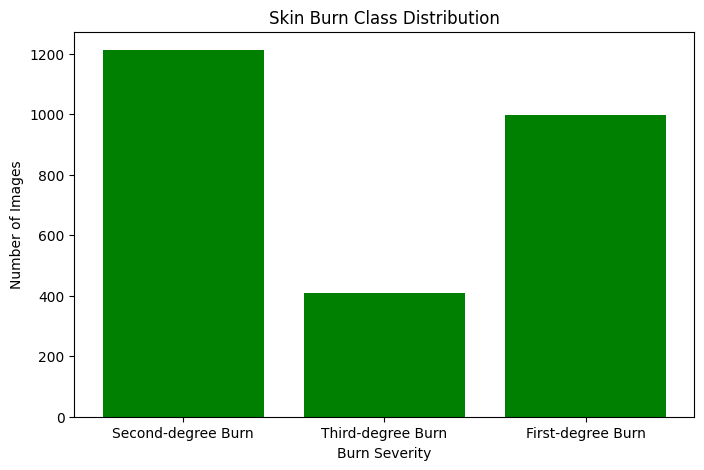

In [13]:
burn_classes = {0: "First-degree Burn", 1: "Second-degree Burn", 2: "Third-degree Burn"}
plt.figure(figsize=(8, 5))
plt.bar([burn_classes[c] for c in class_counts.keys()], class_counts.values(), color= "green")
plt.xlabel("Burn Severity")
plt.ylabel("Number of Images")
plt.title("Skin Burn Class Distribution")
plt.show()

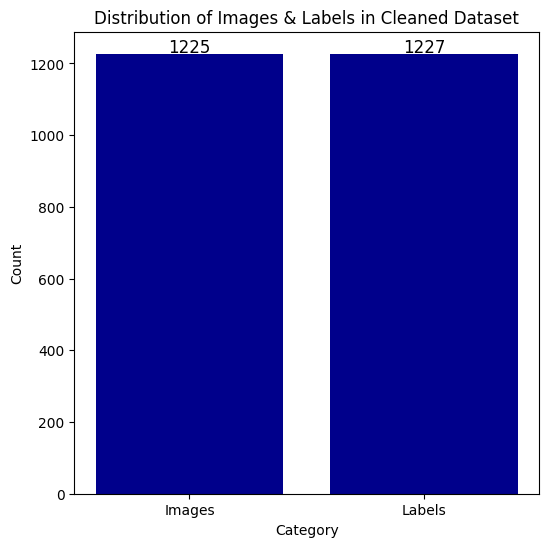

In [14]:
CLEAN_DATASET_PATH = "/kaggle/working/clean-skin-burn-dataset"
image_files = sorted([f for f in os.listdir(CLEAN_DATASET_PATH) if f.endswith((".jpg", ".jpeg", ".png"))])
label_files = sorted([f for f in os.listdir(CLEAN_DATASET_PATH) if f.endswith(".txt")])
num_images = len(image_files)
num_labels = len(label_files)

plt.figure(figsize=(6, 6))
plt.bar(["Images", "Labels"], [num_images, num_labels], color="darkblue")
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Distribution of Images & Labels in Cleaned Dataset")
for i, v in enumerate([num_images, num_labels]):
    plt.text(i, v + 5, str(v), ha="center", fontsize=12)
plt.show()

In [15]:
image_files = {os.path.splitext(f)[0] for f in os.listdir(CLEAN_DATASET_PATH) if f.endswith((".jpg", ".jpeg", ".png"))}
label_files = {os.path.splitext(f)[0] for f in os.listdir(CLEAN_DATASET_PATH) if f.endswith(".txt")}
extra_labels = label_files - image_files

for label in extra_labels:
    label_path = os.path.join(CLEAN_DATASET_PATH, label + ".txt")
    os.remove(label_path)
    print(f"Deleted extra label: {label_path}")
print(f"Removed {len(extra_labels)} extra labels without images!")

Deleted extra label: /kaggle/working/clean-skin-burn-dataset/img1424.txt
Deleted extra label: /kaggle/working/clean-skin-burn-dataset/img1132.txt
Removed 2 extra labels without images!


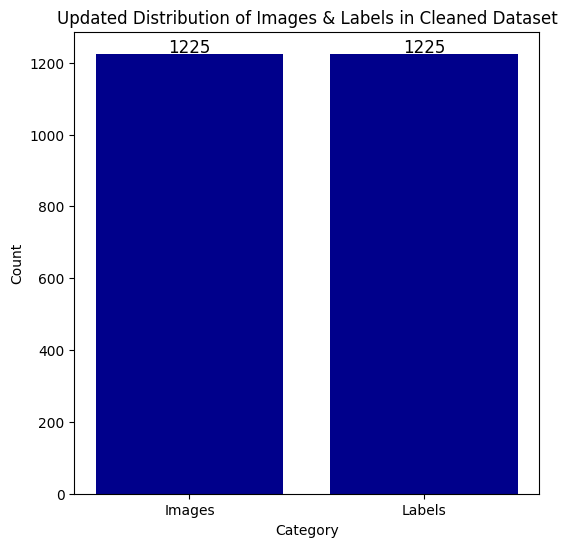

In [51]:
num_images = len([f for f in os.listdir(CLEAN_DATASET_PATH) if f.endswith((".jpg", ".jpeg", ".png"))])
num_labels = len([f for f in os.listdir(CLEAN_DATASET_PATH) if f.endswith(".txt")])
plt.figure(figsize=(6, 6))
plt.bar(["Images", "Labels"], [num_images, num_labels], color="darkblue")
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Updated Distribution of Images & Labels in Cleaned Dataset")
for i, v in enumerate([num_images, num_labels]):
    plt.text(i, v + 5, str(v), ha="center", fontsize=12)
plt.show()

In [17]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 932.9/932.9 kB 15.9 MB/s eta 0:00:00a 0:00:01


In [18]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [19]:
YOLO_DATASET_PATH = "/kaggle/working/yolo-dataset"
os.makedirs(YOLO_DATASET_PATH, exist_ok=True)
os.makedirs(f"{YOLO_DATASET_PATH}/images/train", exist_ok=True)
os.makedirs(f"{YOLO_DATASET_PATH}/images/val", exist_ok=True)
os.makedirs(f"{YOLO_DATASET_PATH}/labels/train", exist_ok=True)
os.makedirs(f"{YOLO_DATASET_PATH}/labels/val", exist_ok=True)

image_files = sorted([f for f in os.listdir(CLEAN_DATASET_PATH) if f.endswith((".jpg", ".jpeg", ".png"))])
label_files = sorted([f for f in os.listdir(CLEAN_DATASET_PATH) if f.endswith(".txt")])

split_idx = int(len(image_files) * 0.8)
train_images, val_images = image_files[:split_idx], image_files[split_idx:]

for img in train_images:
    shutil.copy(os.path.join(CLEAN_DATASET_PATH, img), f"{YOLO_DATASET_PATH}/images/train/{img}")
    label = img.replace(".jpg", ".txt").replace(".jpeg", ".txt").replace(".png", ".txt")
    shutil.copy(os.path.join(CLEAN_DATASET_PATH, label), f"{YOLO_DATASET_PATH}/labels/train/{label}")

for img in val_images:
    shutil.copy(os.path.join(CLEAN_DATASET_PATH, img), f"{YOLO_DATASET_PATH}/images/val/{img}")
    label = img.replace(".jpg", ".txt").replace(".jpeg", ".txt").replace(".png", ".txt")
    shutil.copy(os.path.join(CLEAN_DATASET_PATH, label), f"{YOLO_DATASET_PATH}/labels/val/{label}")

print(f" Dataset prepared in YOLOv8 format at {YOLO_DATASET_PATH}")

 Dataset prepared in YOLOv8 format at /kaggle/working/yolo-dataset


In [20]:
data_yaml = f"""
path: {YOLO_DATASET_PATH}
train: images/train
val: images/val
nc: 3
names: ['First-degree Burn', 'Second-degree Burn', 'Third-degree Burn']
"""
with open(f"{YOLO_DATASET_PATH}/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml file created successfully!")

data.yaml file created successfully!


In [21]:
model = YOLO("yolov8s.pt") 
model.train(
    data=f"{YOLO_DATASET_PATH}/data.yaml",
    epochs=100,
    imgsz=640,
    patience = 20,
    batch=16,
    device="cuda"
)
print("YOLOv8 Training Completed!")

100%|██████████| 21.5M/21.5M [00:00<00:00, 177MB/s]


Ultralytics 8.3.88 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/kaggle/working/yolo-dataset/data.yaml, epochs=100, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True

100%|██████████| 755k/755k [00:00<00:00, 18.0MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 76.5MB/s]


...


62 epochs completed in 0.322 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 22.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.88 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.20it/s]


                   all        245        482       0.39      0.259      0.235      0.088
     First-degree Burn         96        162      0.341      0.105      0.117     0.0331
    Second-degree Burn        117        244      0.455       0.25      0.228     0.0745
     Third-degree Burn         51         76      0.372      0.421      0.361      0.156


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 3.8ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to runs/detect/train
YOLOv8 Training Completed!


In [22]:
model.tune(data=f"{YOLO_DATASET_PATH}/data.yaml", epochs=50)

Tuner: Initialized Tuner instance with 'tune_dir=runs/detect/train2'
Tuner: 💡 Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/10 with hyperparameters: {'lr0': 0.01, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'warmup_epochs': 3.0, 'warmup_momentum': 0.8, 'box': 7.5, 'cls': 0.5, 'dfl': 1.5, 'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0, 'perspective': 0.0, 'flipud': 0.0, 'fliplr': 0.5, 'bgr': 0.0, 'mosaic': 1.0, 'mixup': 0.0, 'copy_paste': 0.0}
Saved runs/detect/train2/tune_scatter_plots.png
Saved runs/detect/train2/tune_fitness.png

Tuner: 1/10 iterations complete ✅ (966.22s)
Tuner: Results saved to runs/detect/train2
Tuner: Best fitness=0.10964 observed at iteration 1
Tuner: Best fitness metrics are {'metrics/precision(B)': 0.44854, 'metrics/recall(B)': 0.27321, 'metrics/mAP50(B)': 0.24214, 'metrics/mAP50-95(B)': 0.09492, 'val/box_loss': 2.57088, 'val/cls_

In [23]:
metrics = model.val()

Ultralytics 8.3.88 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning /kaggle/working/yolo-dataset/labels/val.cache... 245 images, 0 backgrounds, 0 corrupt: 100%|██████████| 245/245 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 16/16 [00:03<00:00,  4.52it/s]


                   all        245        482      0.469      0.245      0.234     0.0883
     First-degree Burn         96        162      0.442     0.0926      0.117     0.0342
    Second-degree Burn        117        244      0.487      0.233      0.228     0.0752
     Third-degree Burn         51         76      0.479      0.408      0.356      0.156


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 1.0ms preprocess, 9.0ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/train13


In [ ]:
"""WORKING_DIR = "/kaggle/working/"
for root, dirs, files in os.walk(WORKING_DIR):
    print(f"\n Directory: {root}")
    for file in files:
        print(f"    {file}")"""

Showing F1_curve.png:



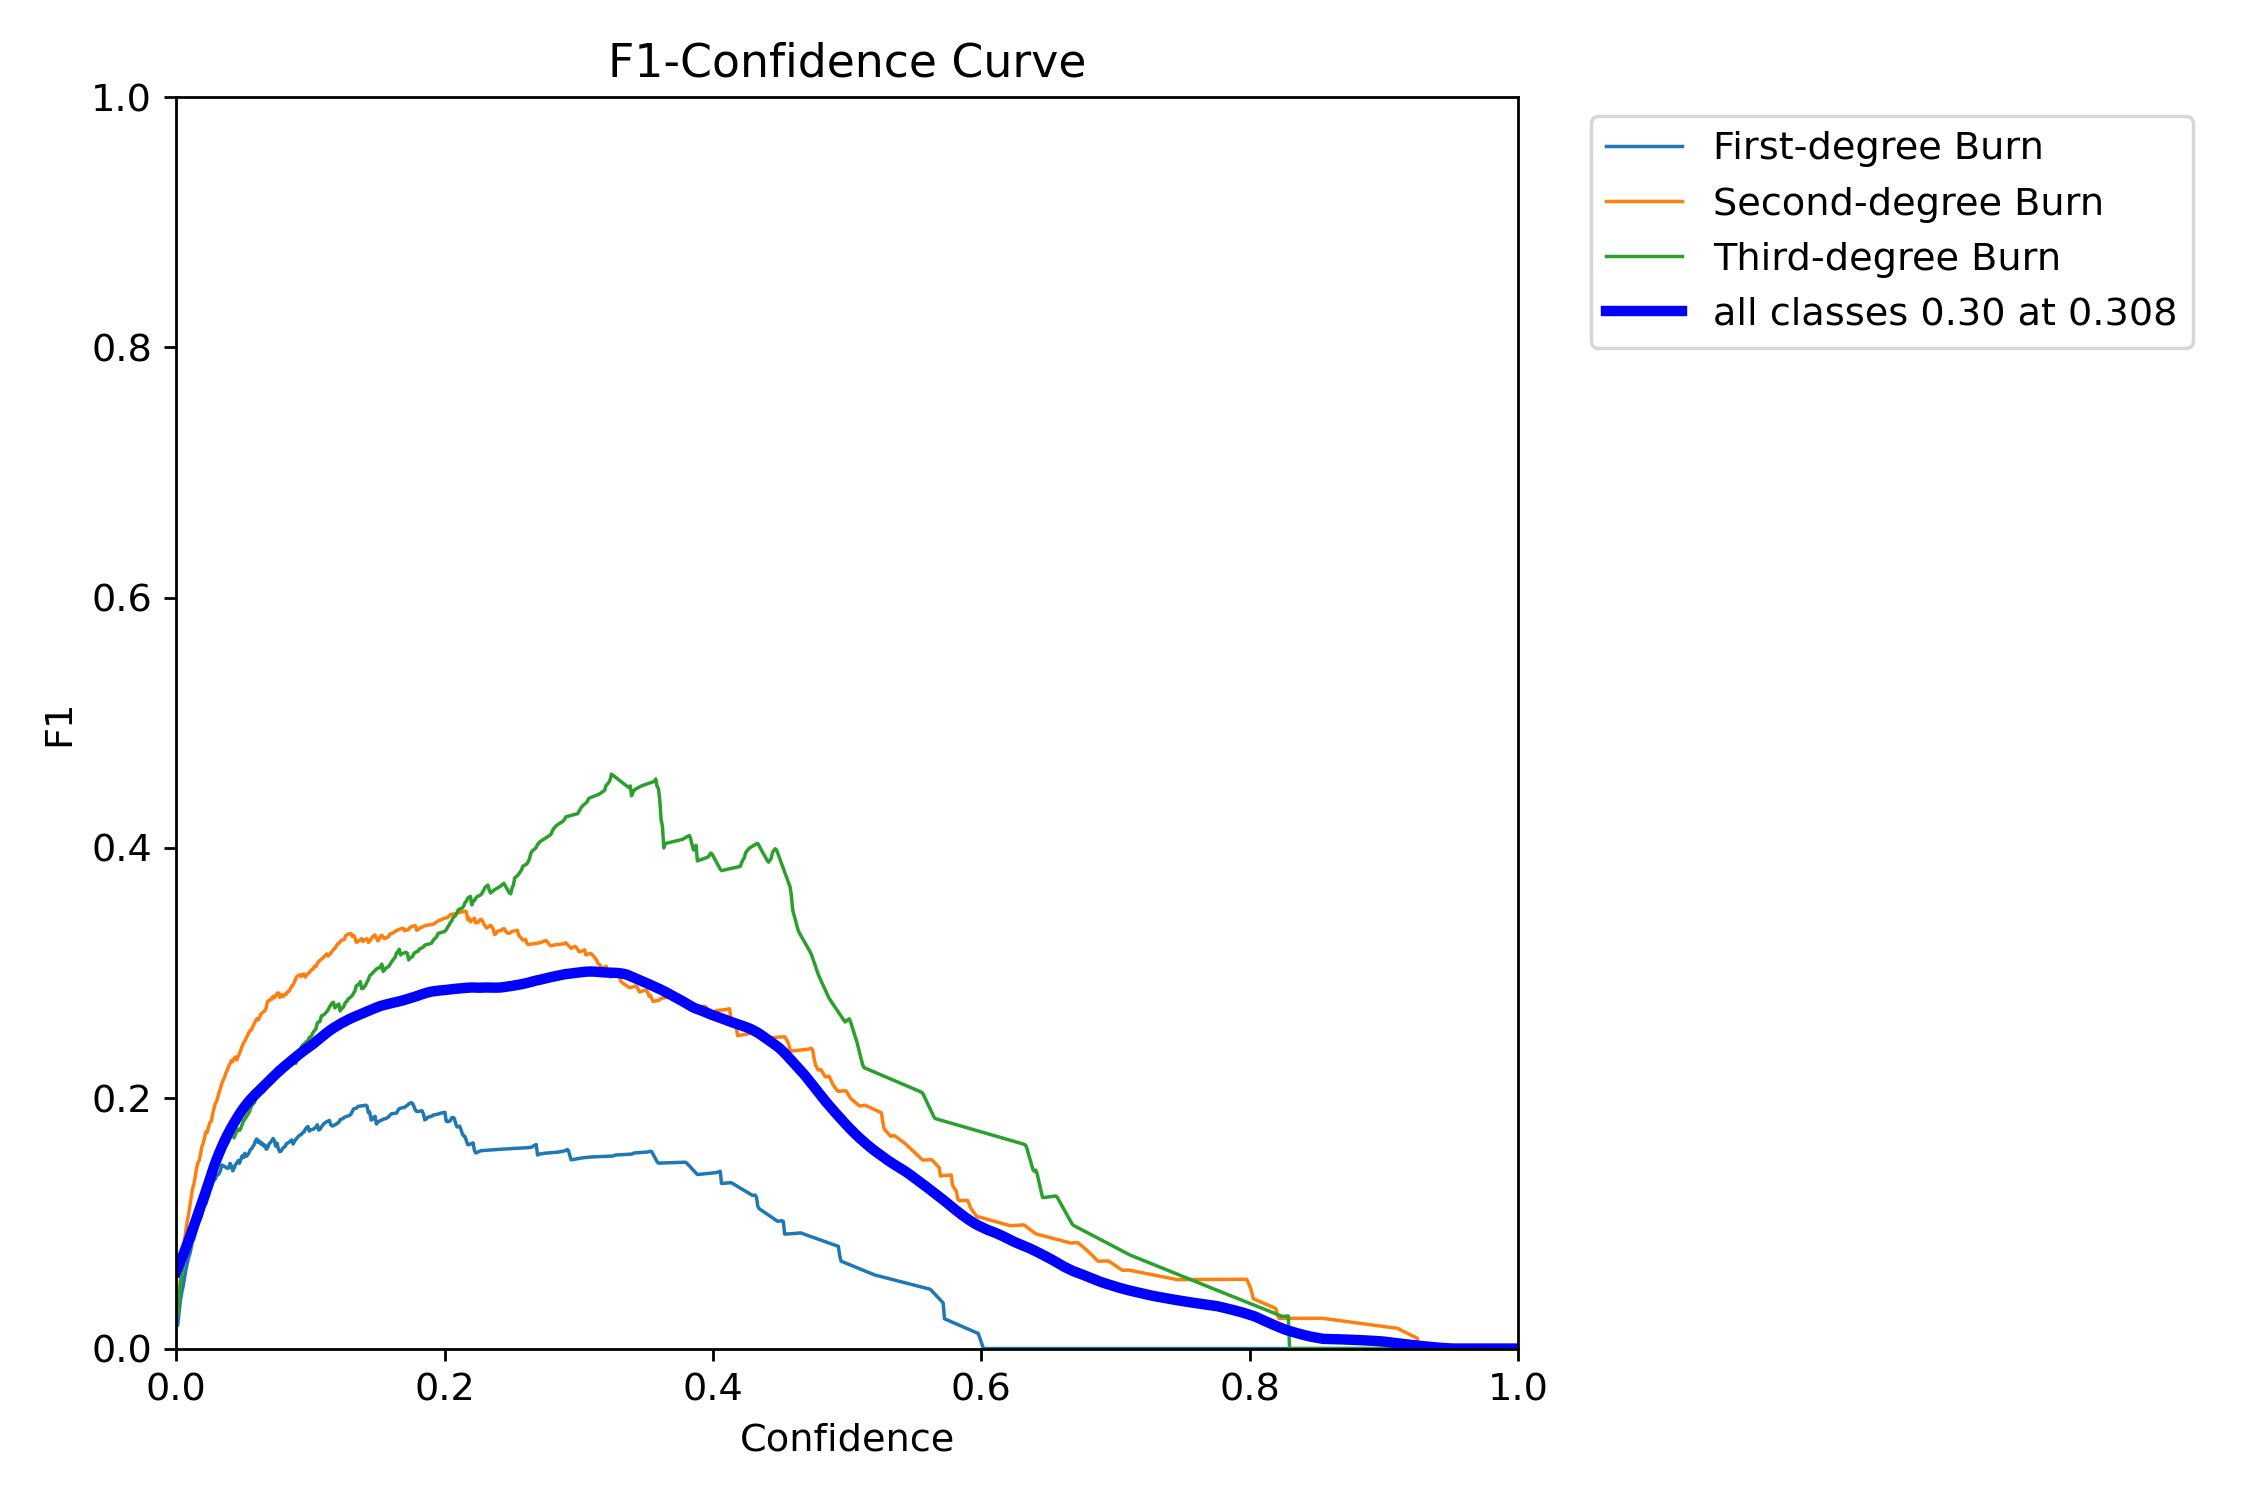

Showing PR_curve.png:



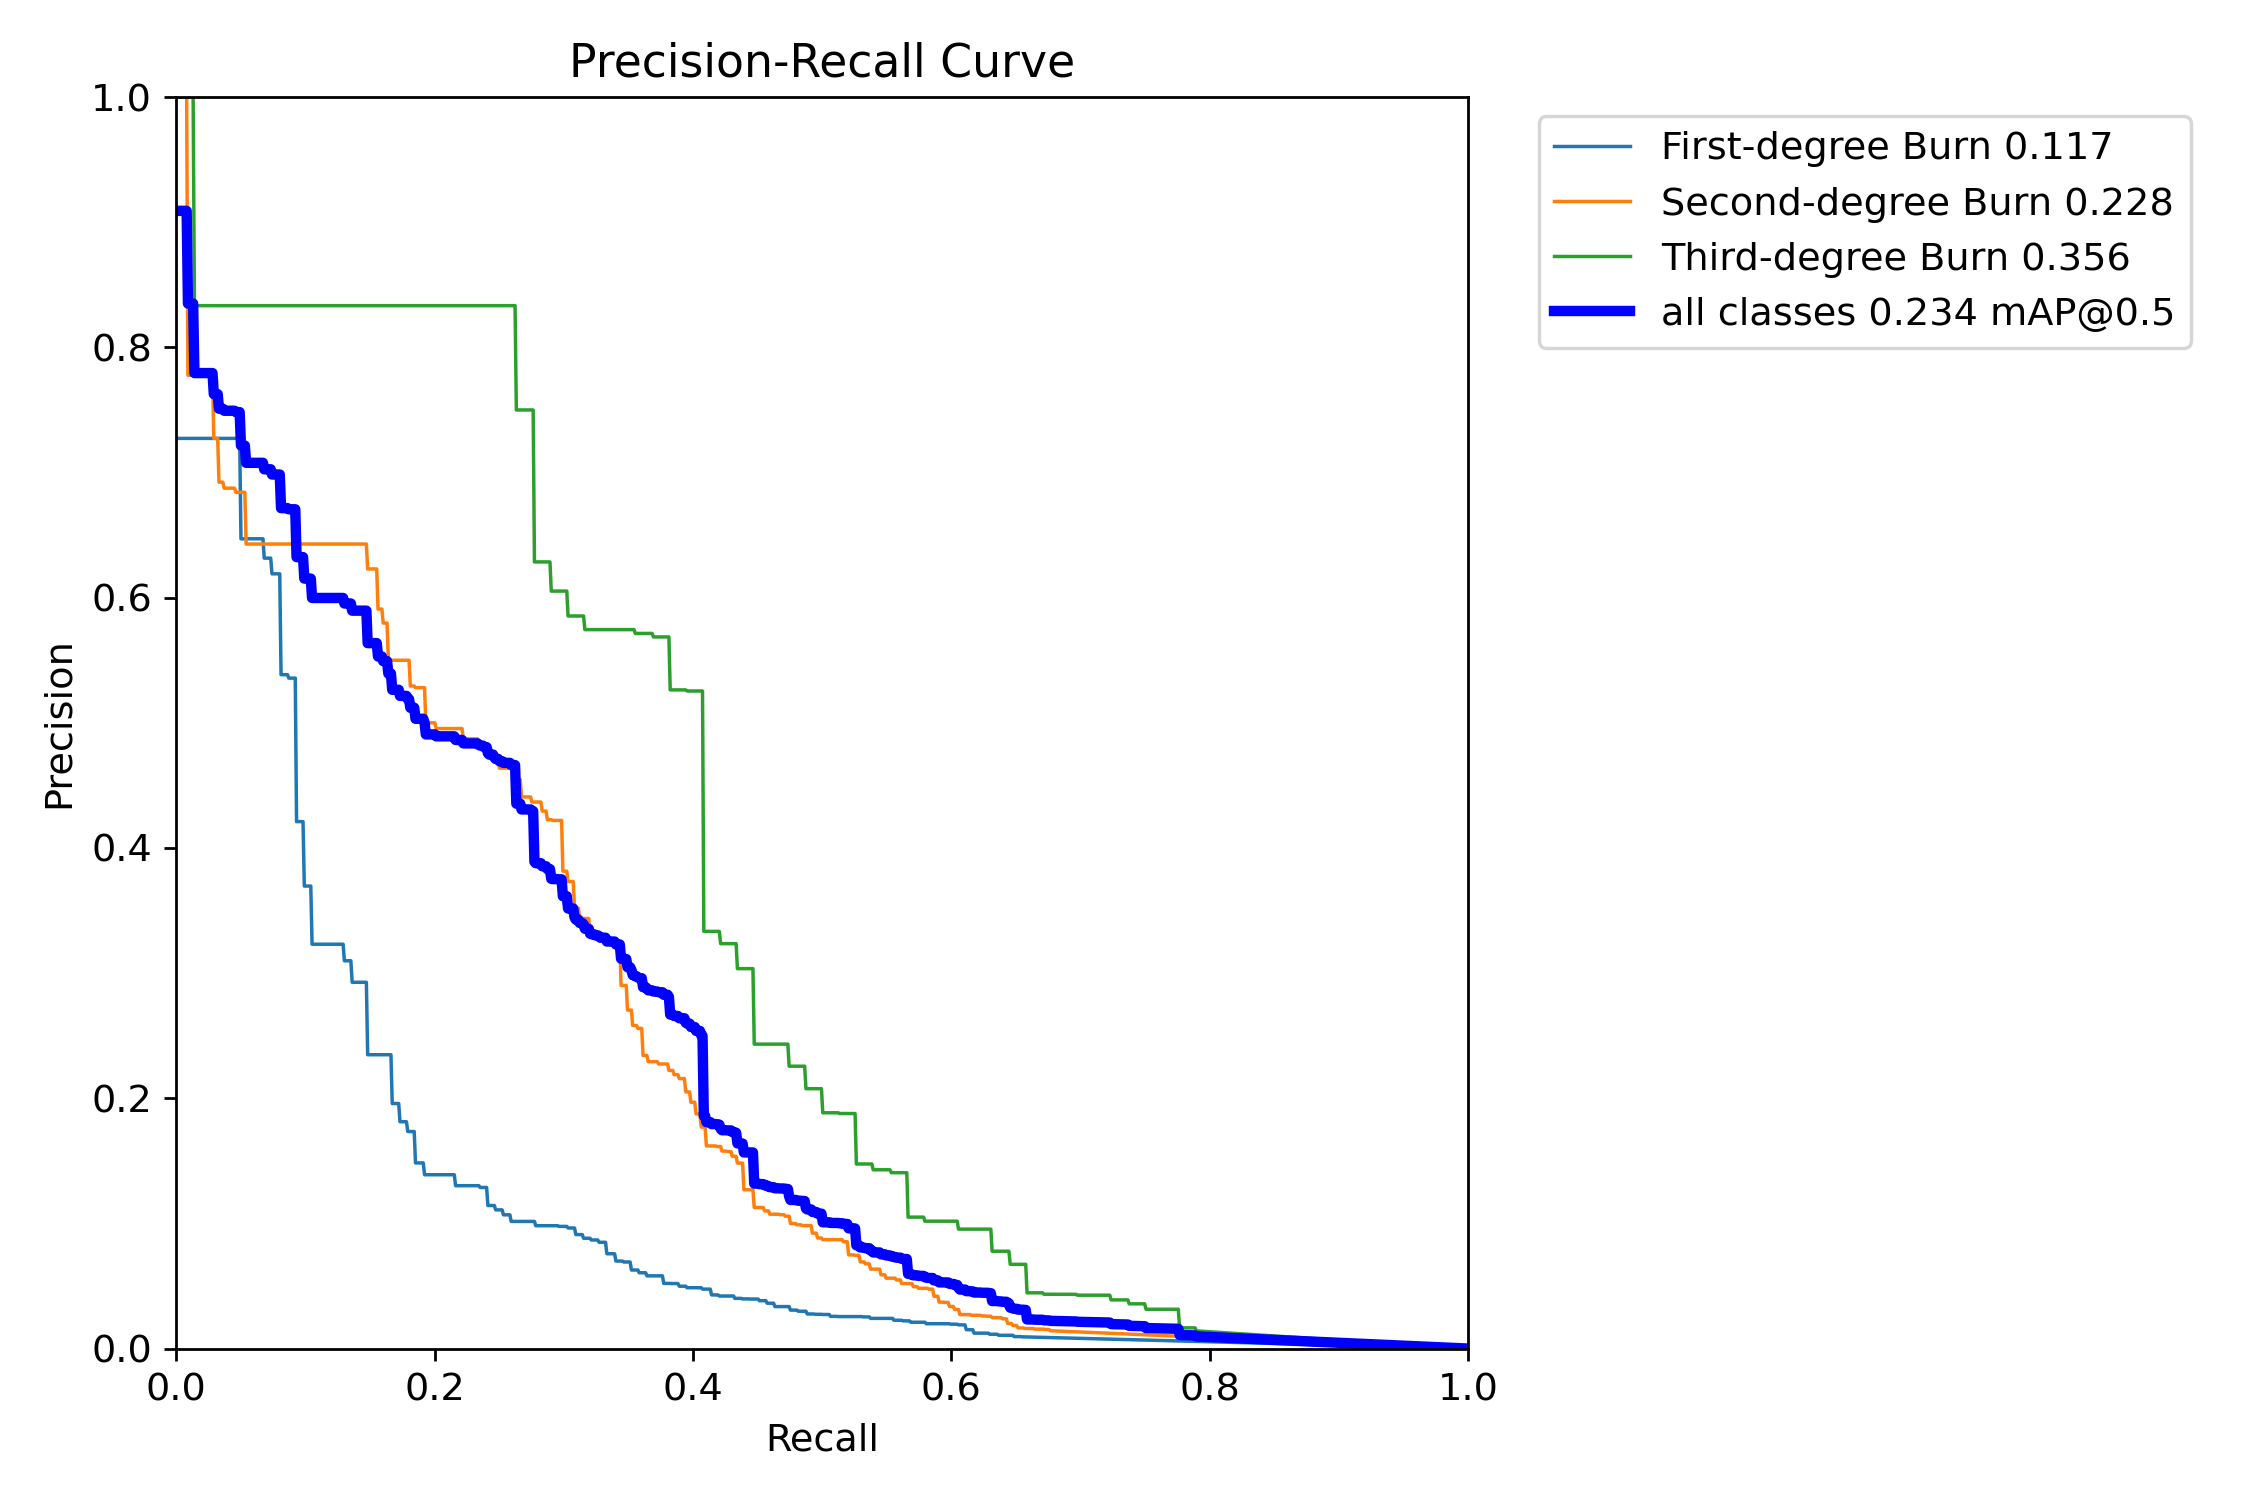

Showing P_curve.png:



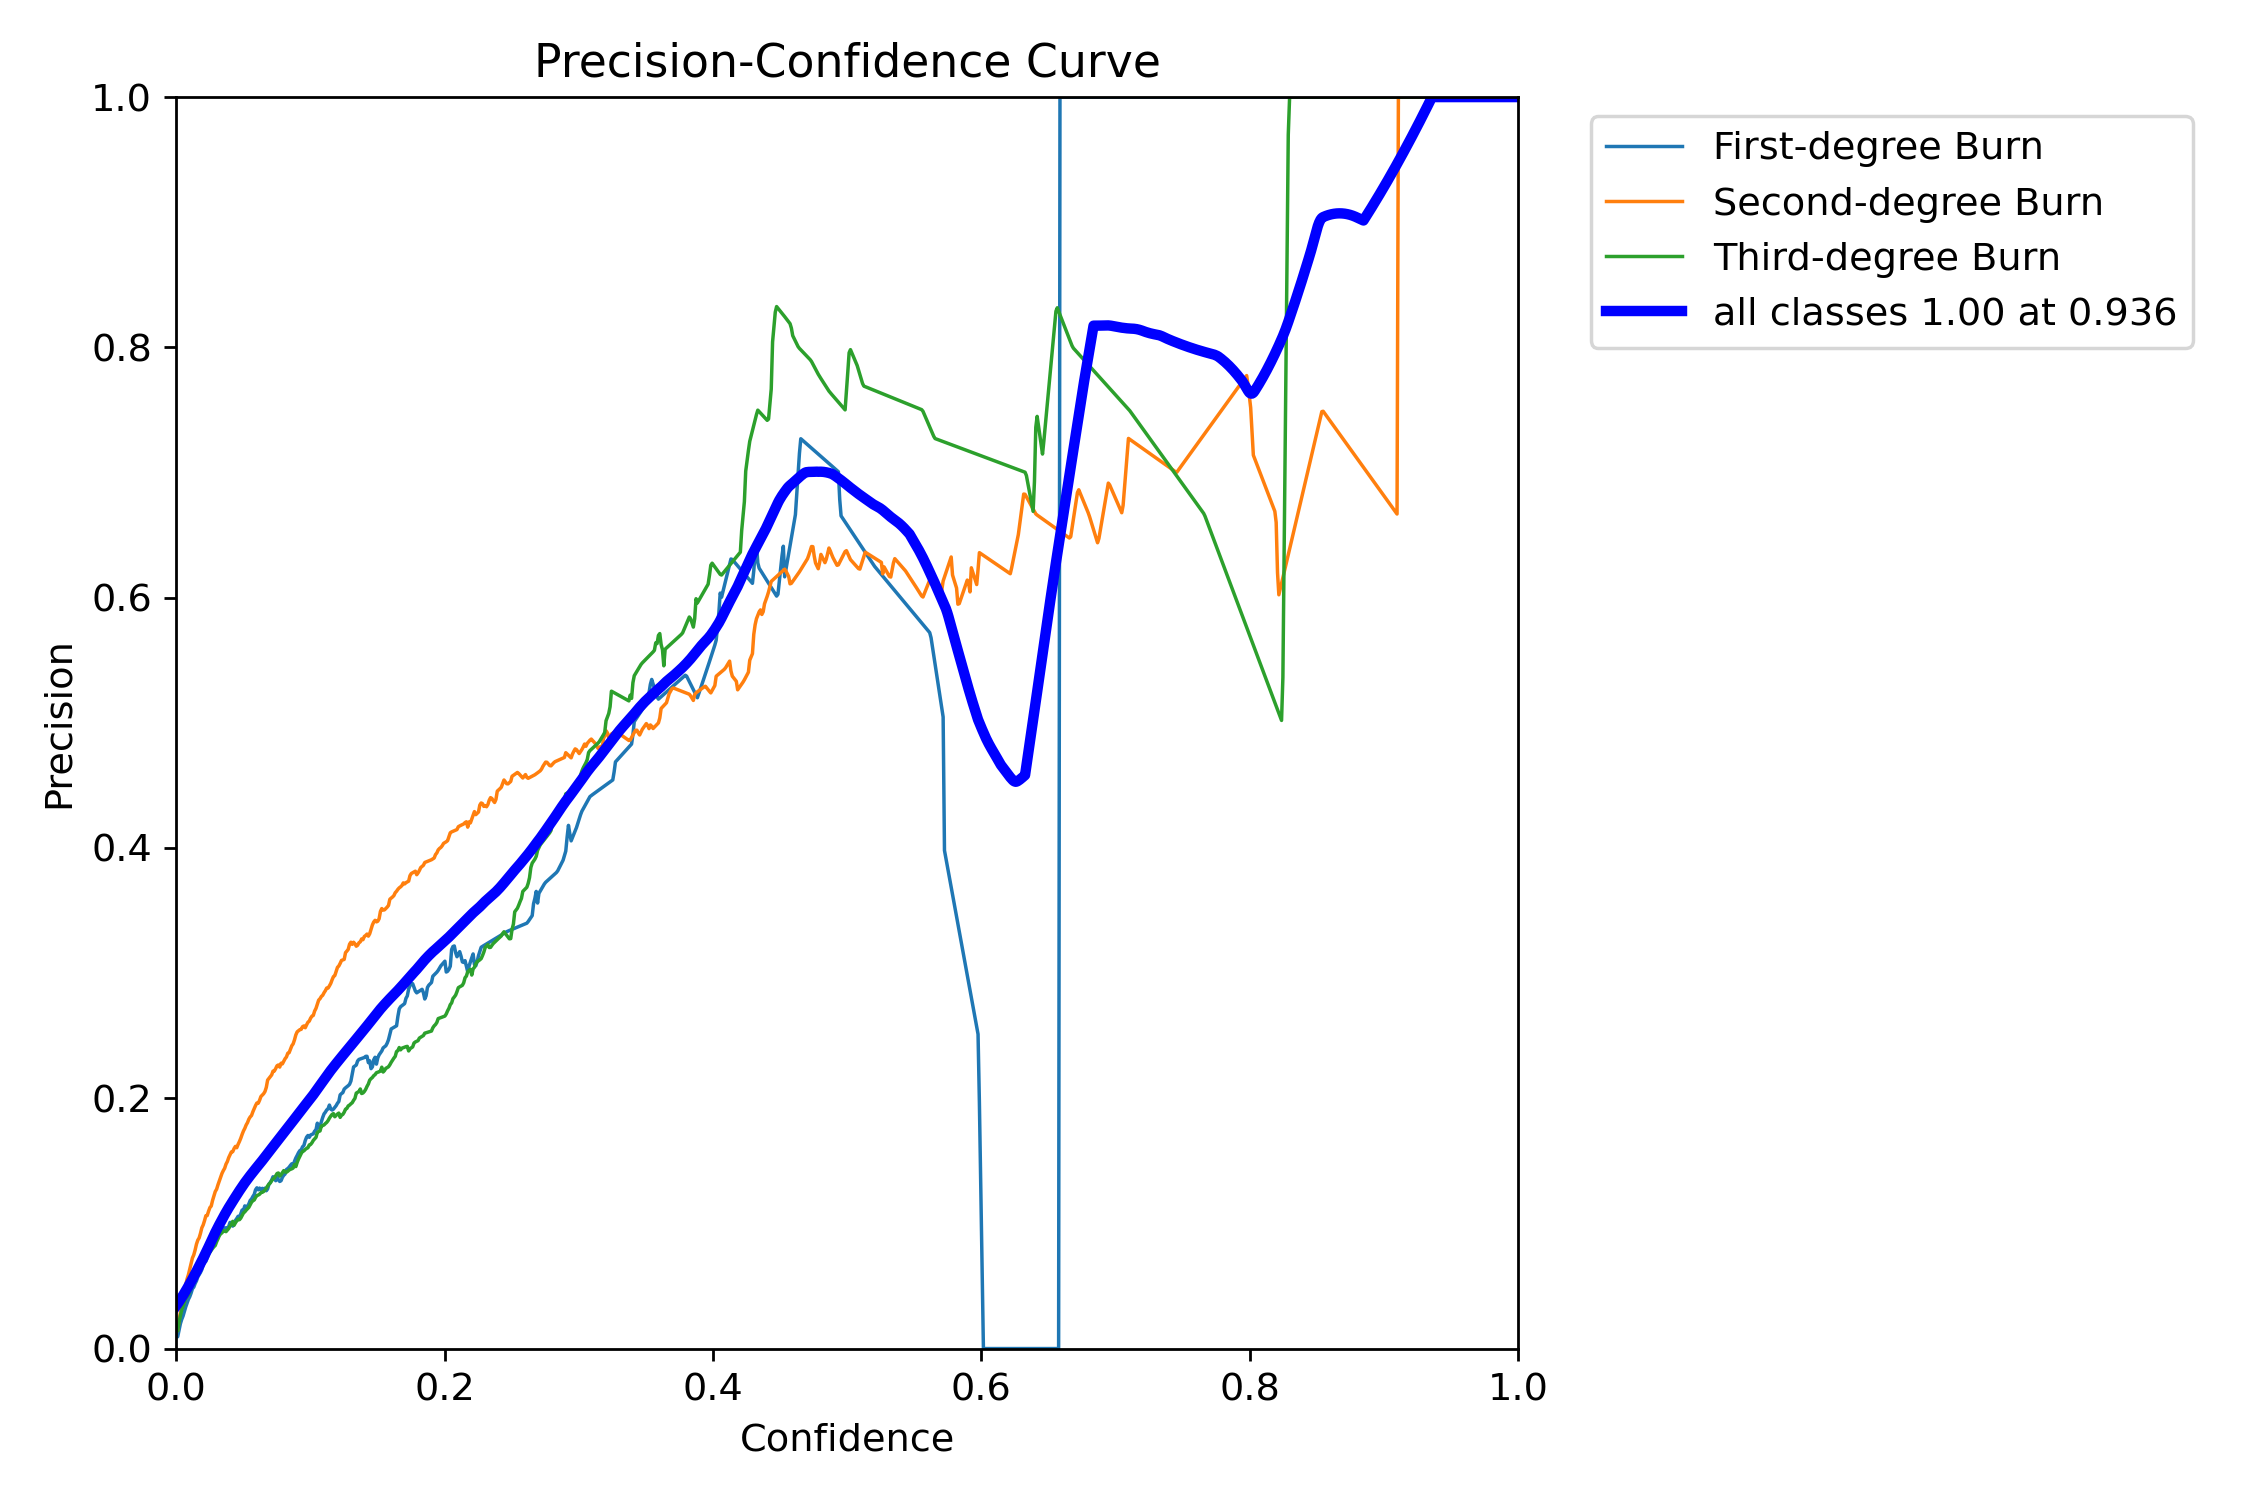

Showing R_curve.png:



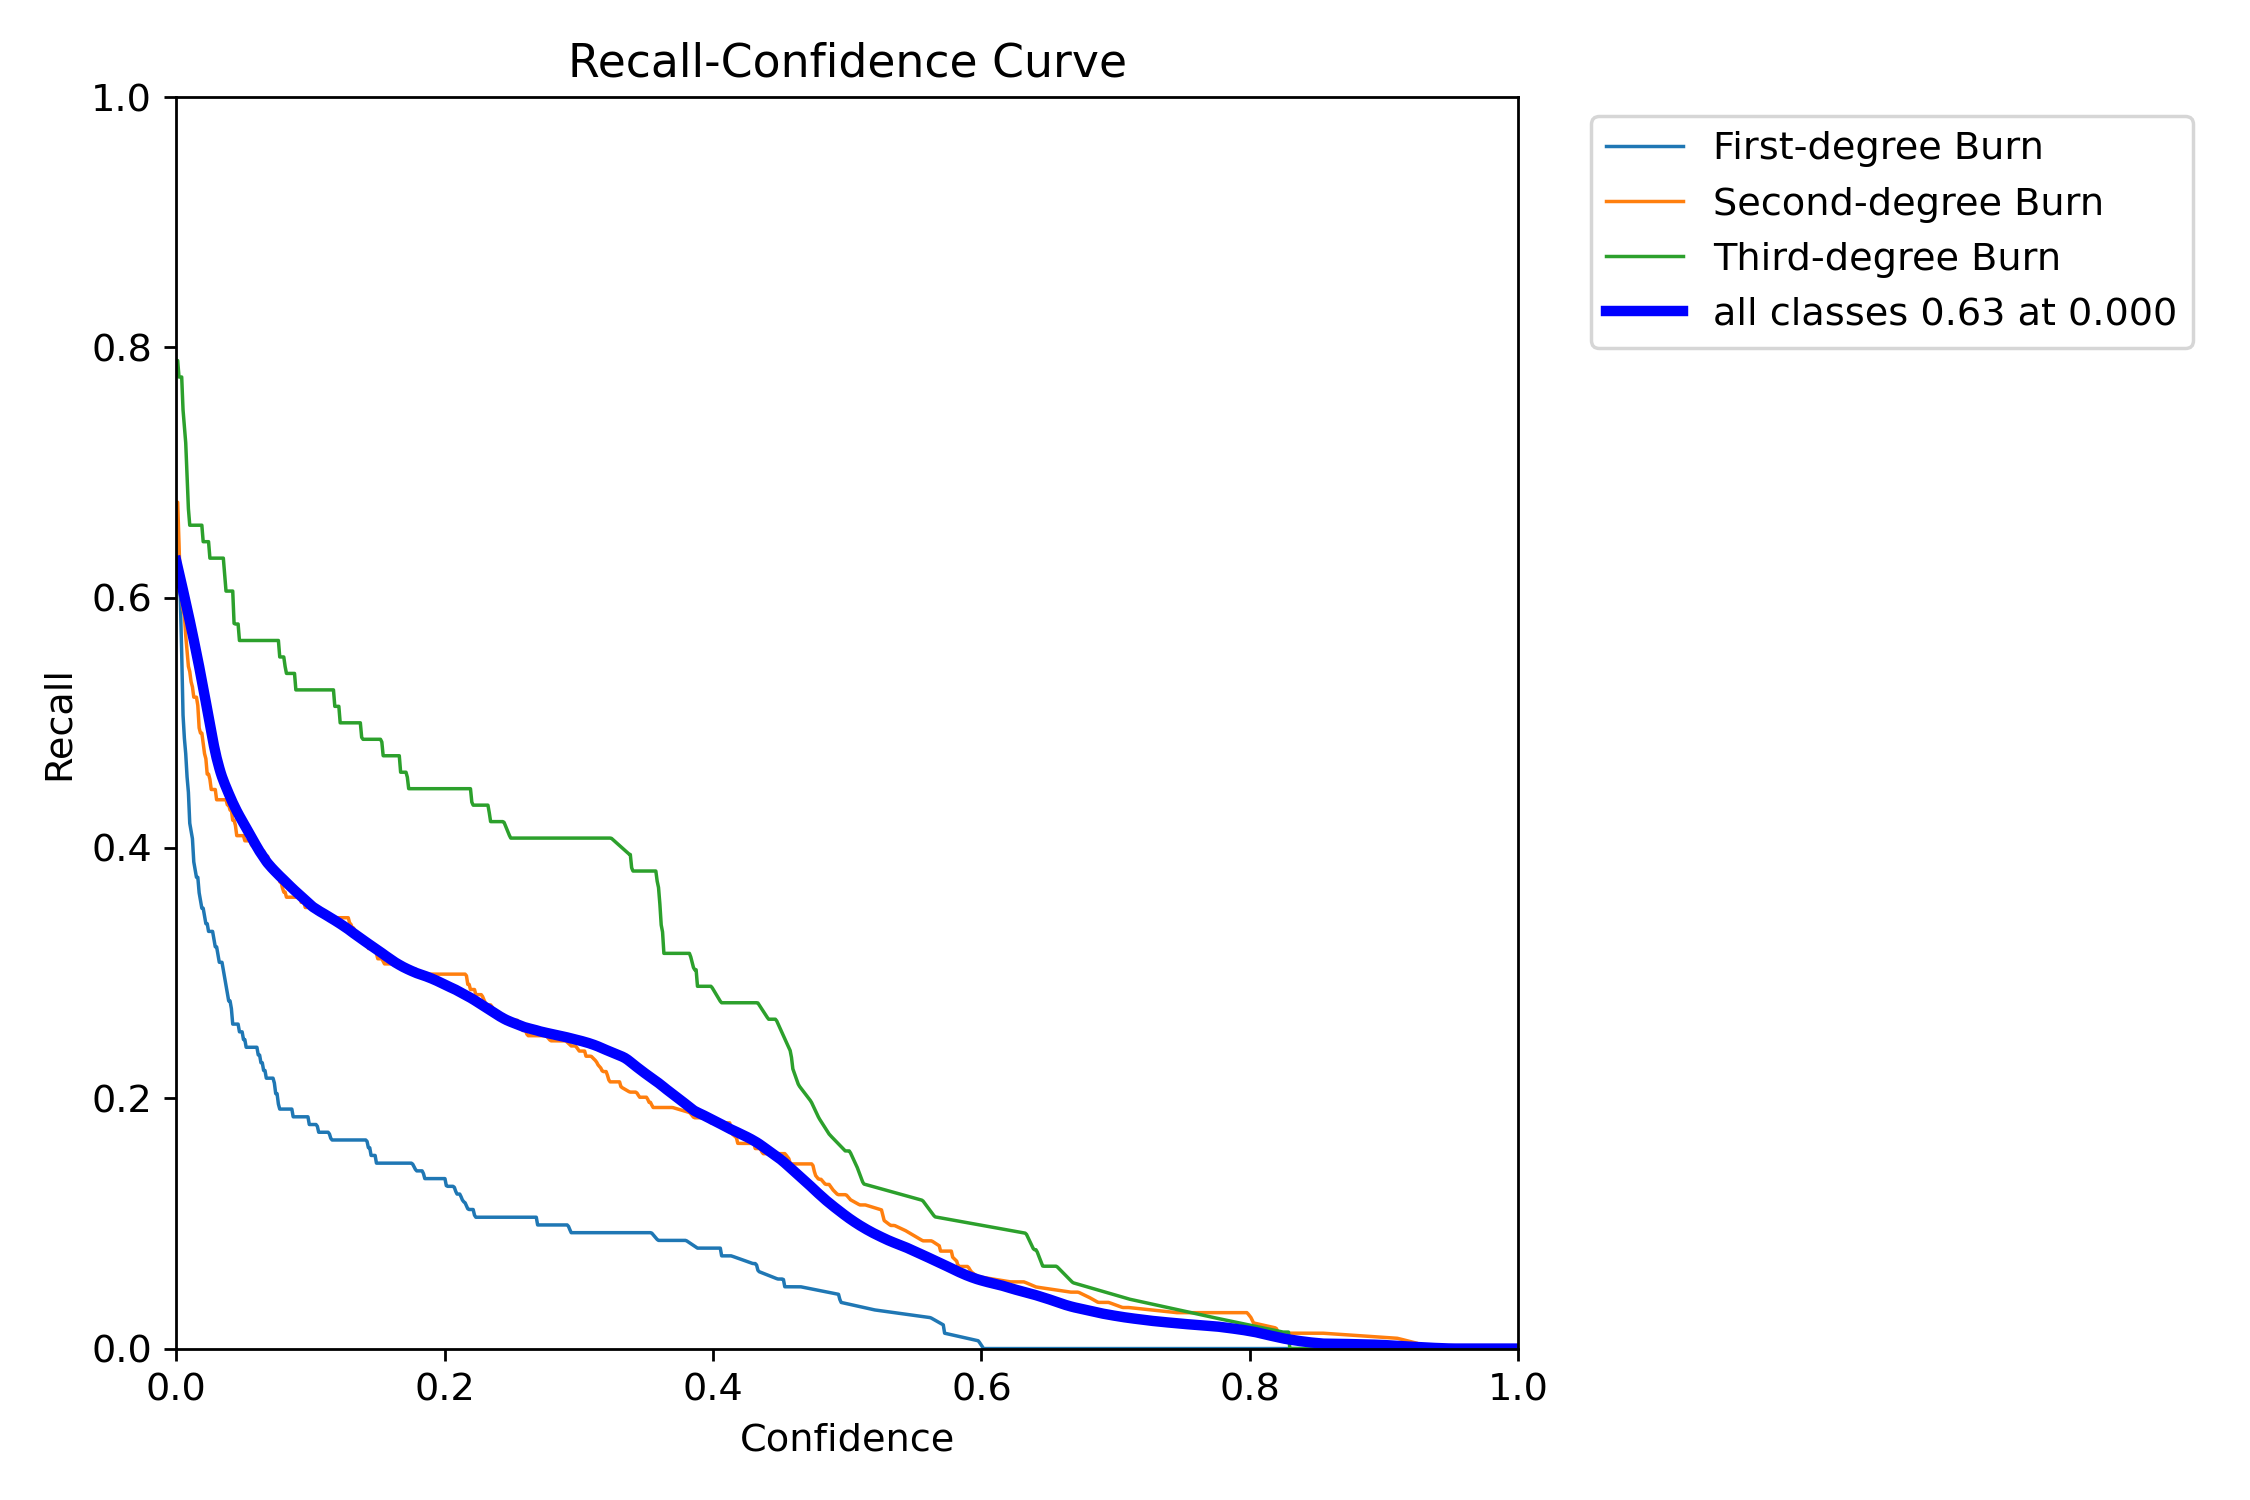

Showing confusion_matrix.png:



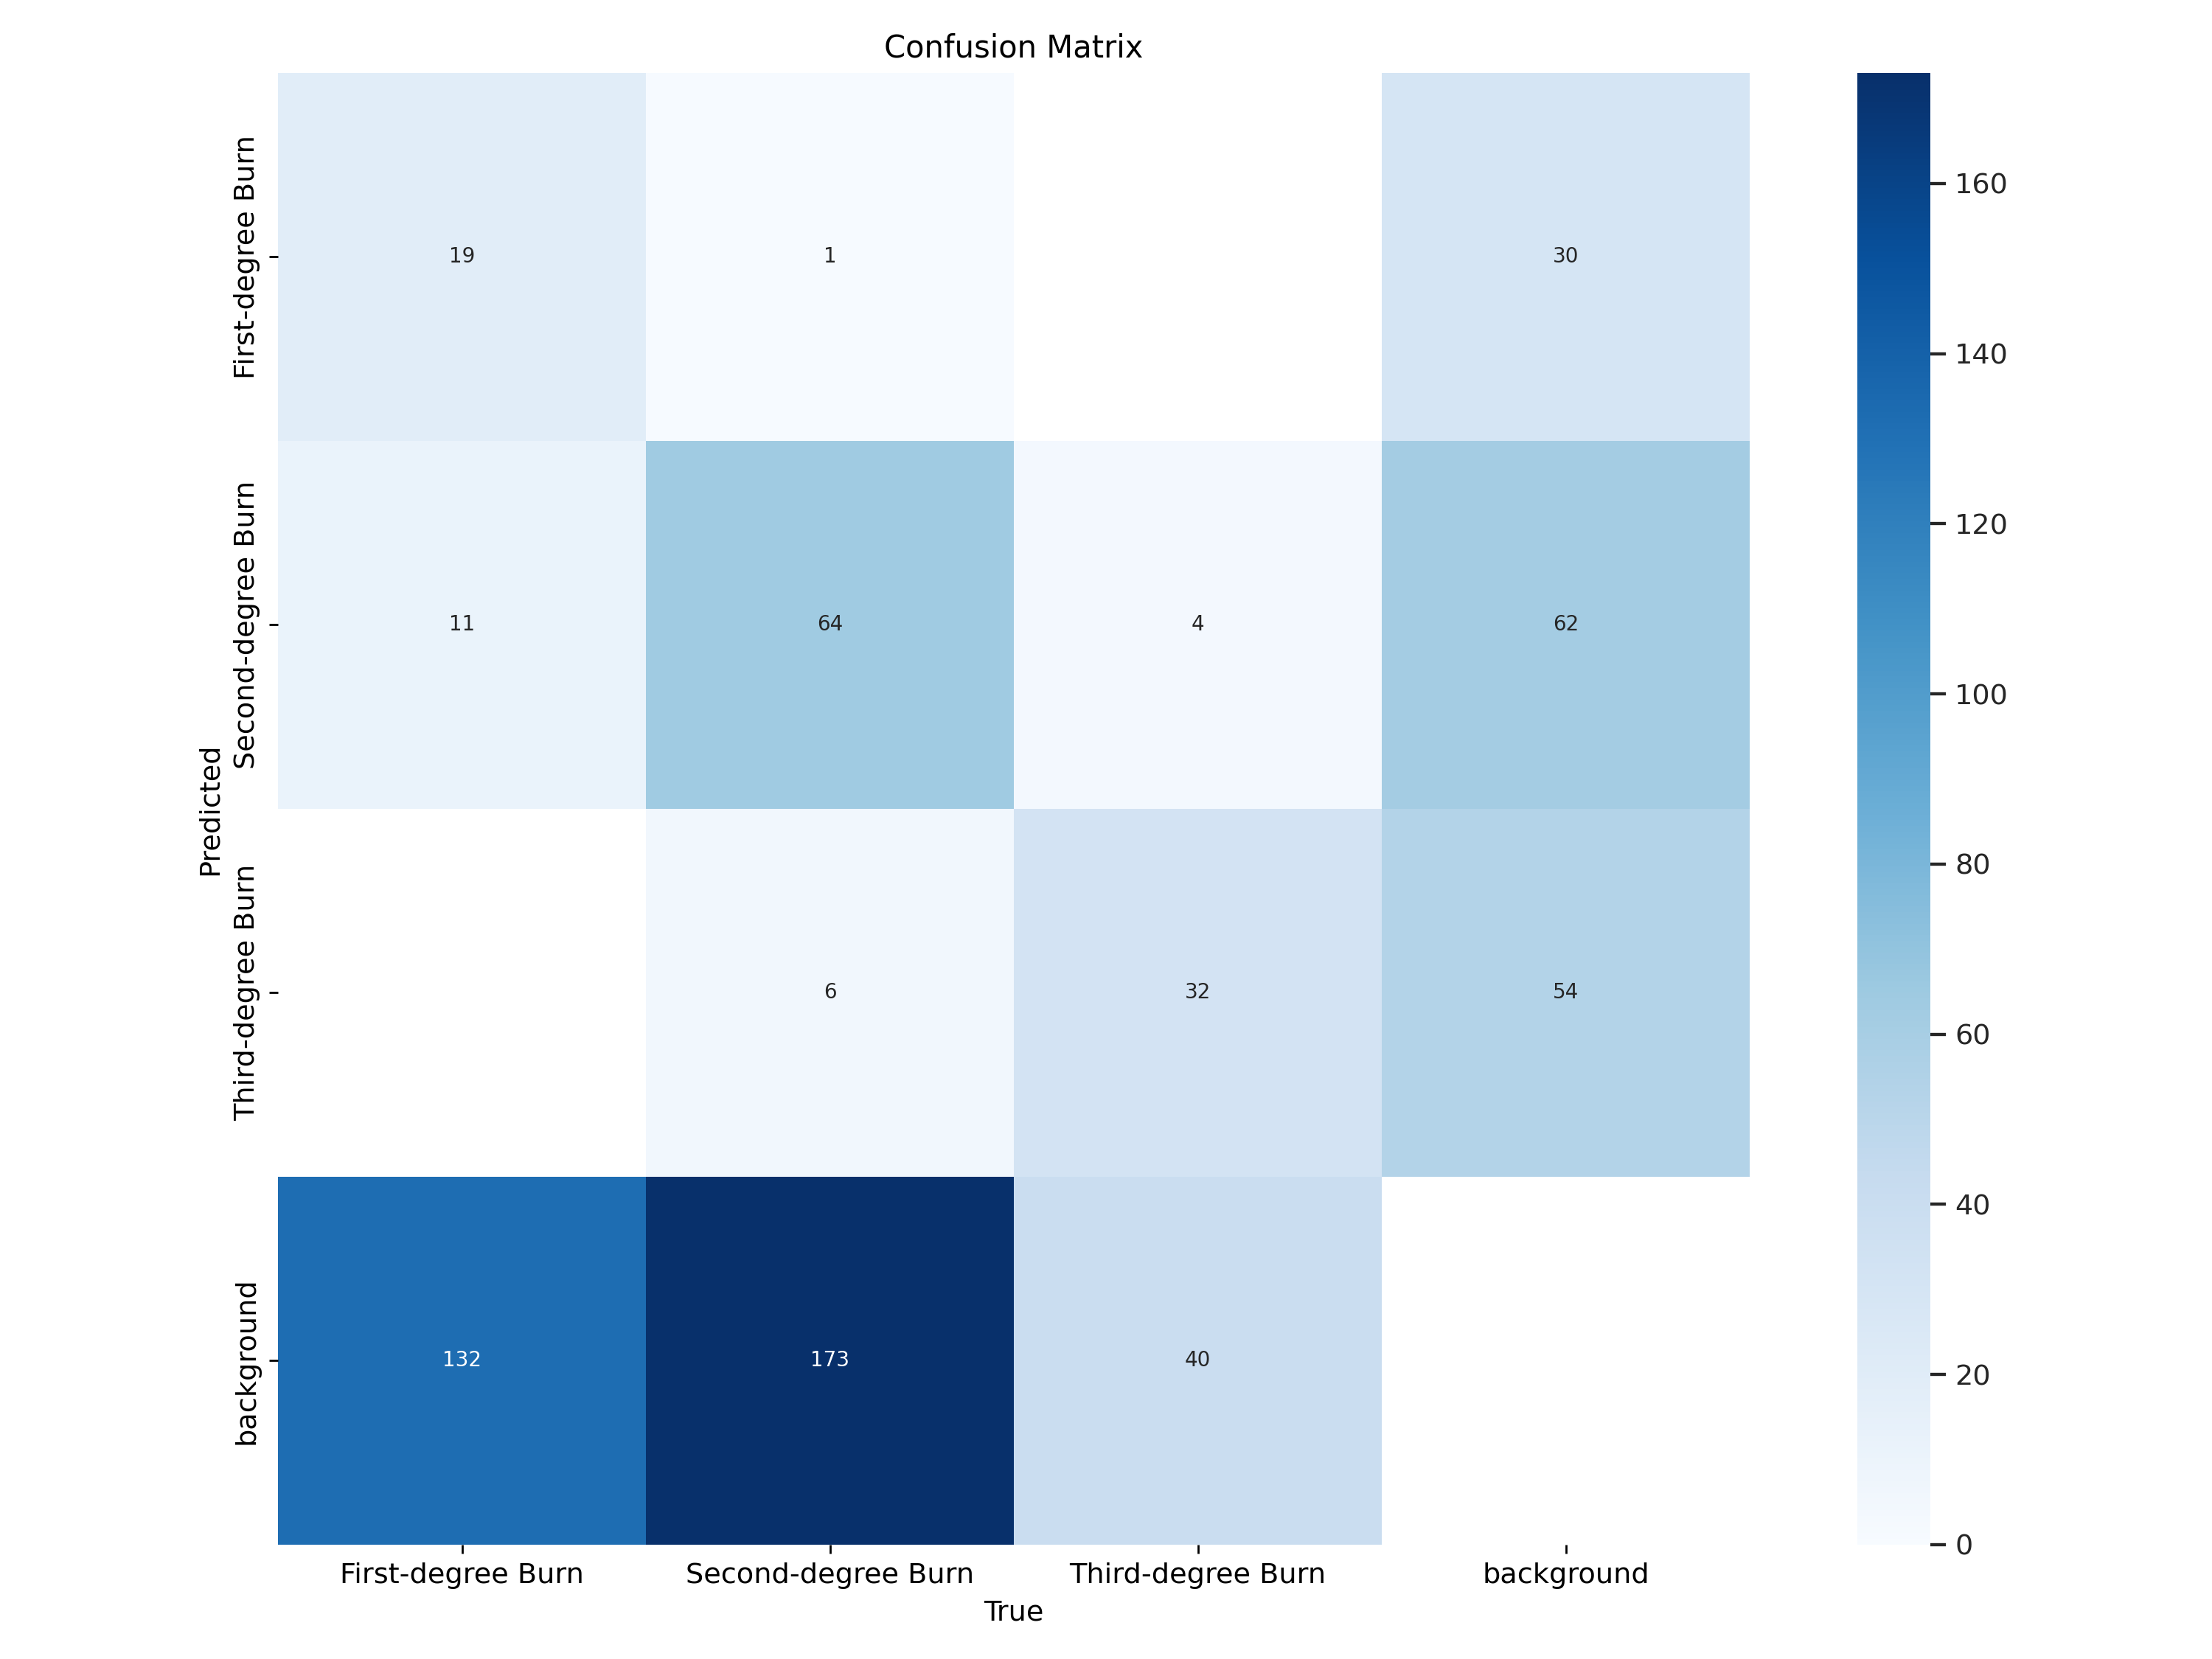

Showing confusion_matrix_normalized.png:



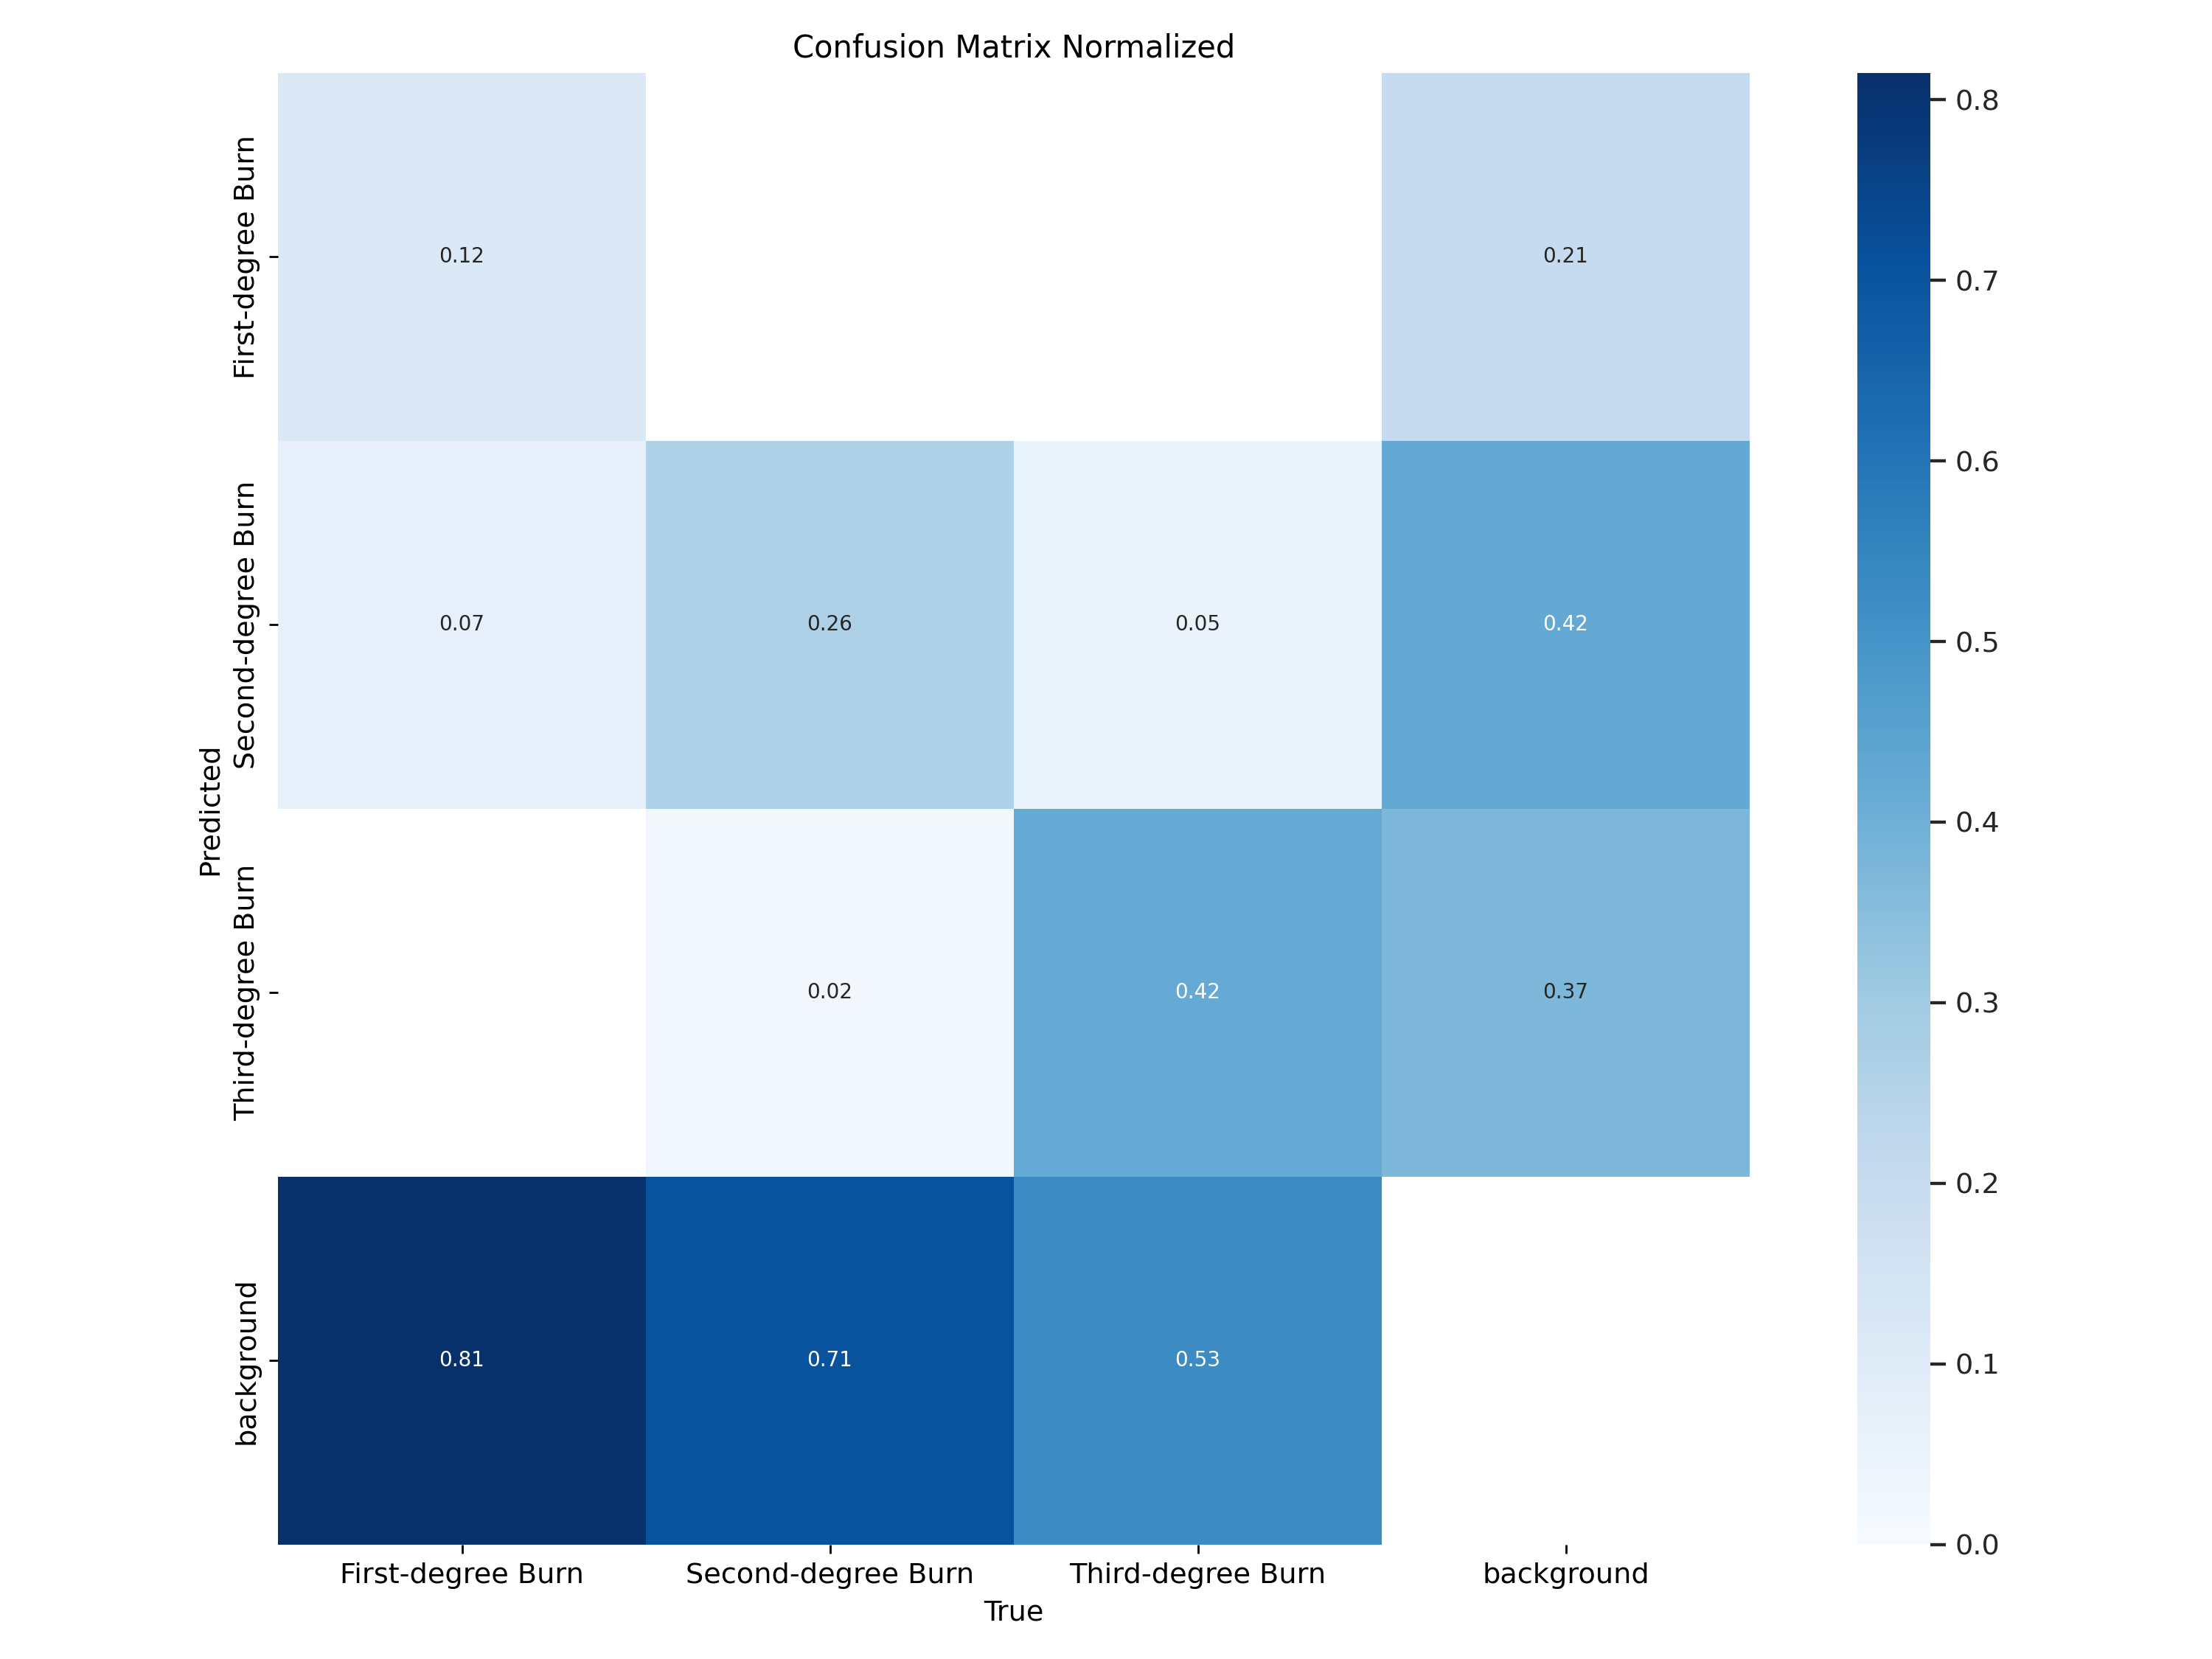

In [33]:
RESULTS_PATH = "/kaggle/working/runs/detect/train13/"
plots = [
    "F1_curve.png",               
    "PR_curve.png",              
    "P_curve.png",               
    "R_curve.png",                
    "confusion_matrix.png",      
    "confusion_matrix_normalized.png", 
]
for plot in plots:
    plot_path = os.path.join(RESULTS_PATH, plot)
    if os.path.exists(plot_path):
        print(f"Showing {plot}:\n")
        display.display(Image.open(plot_path))
    else:
        print(f"\n{plot} not found!")

In [25]:
model.export(format="onnx")
best_model_path = "runs/detect/train/weights/best.pt"
shutil.copy(best_model_path, "/kaggle/working/best_yolo_model.pt")
print("Model exported successfully for deployment!")

Ultralytics 8.3.88 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.00GHz)

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnxslim', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.8/280.8 MB 212.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 187.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 298.1 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 12.4s, installed 2 packages: ['onnxslim', 'onnxruntime-gpu']
requirements: ⚠️ Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.48...
ONNX: export success ✅ 14.2s, saved as 'runs/detect/train/weights/best.onnx' (42.7 M